In [1]:
import numpy as np
import matplotlib.pyplot as plt

# K-Armed Bandit

In [2]:
class KArmedBandit:
    def __init__(self, k=10, stationary=True, reward_std=0.01, seed=None):
        self.k = k
        self.stationary = stationary
        self.reward_std = reward_std
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.q_true = self.rng.normal(0.0, 1.0, size=self.k)
        return self.q_true.copy()

    def step(self, action):
        # reward noise variance = 1
        reward = self.rng.normal(self.q_true[action], 1.0)

        if not self.stationary:
            # random walk on true values
            self.q_true += self.rng.normal(0.0, self.reward_std, size=self.k)

        optimal_action = int(np.argmax(self.q_true))
        return reward, optimal_action

# $\varepsilon$-Greedy Action Selection

In [3]:
class EpsilonGreedy:
    def __init__(self, k=10, epsilon=0.1, alpha=None, q_init=0.0, seed=None):
        self.k = k
        self.epsilon = epsilon
        self.alpha = alpha  # if None => sample-average
        self.q_init = q_init
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.Q = np.full(self.k, self.q_init, dtype=float)
        self.N = np.zeros(self.k, dtype=int)

    def act(self):
        if self.rng.random() < self.epsilon:
            return self.rng.integers(self.k)
        else:
            max_indices = np.flatnonzero(self.Q == np.max(self.Q))
            return self.rng.choice(max_indices)
       # TODO (Task 1):
        # With probability epsilon select a uniformly random arm.
        # Otherwise select argmax Q, breaking ties uniformly at random.

    def update(self, a, r):
        self.N[a] += 1
        if self.alpha is None:
            self.Q[a] += (r - self.Q[a]) / self.N[a]
        else:
            self.Q[a] += self.alpha * (r - self.Q[a])
        #self.mean = (self.mean * (self.N[a] - 1) + r) / self.N[a]
        # TODO (Task 1):
        # Increment N[a] and update Q[a].
        # Use sample-average if self.alpha is None, constant step-size otherwise.


# Upper-Confidence-Bound Action Selection

In [4]:
class UCB:
    def __init__(self, k=10, c=2.0, alpha=None, q_init=0.0, seed=None):
        self.k = k
        self.c = c
        self.alpha = alpha  # if None => sample-average
        self.q_init = q_init
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.Q = np.full(self.k, self.q_init, dtype=float)
        self.N = np.zeros(self.k, dtype=int)
        self.t = 0
    
    def act(self):
        self.t += 1
        if self.t <= self.k:
            perm = self.rng.permutation(self.k)
            return perm[self.t - 1]
        else:
            ucb = self.Q + self.c * np.sqrt(np.log(self.t) / np.maximum(self.N, 1))
            max_indices = np.flatnonzero(ucb == ucb.max())
            return self.rng.choice(max_indices)
            # TODO (Task 2):
            # Increment self.t.
            # On the first k steps, try each arm at least once (in random order).
            # Afterwards select argmax [Q + c * sqrt(ln(t) / N)],
            # breaking ties uniformly at random.

    def update(self, a, r):
        self.N[a] += 1
        if self.alpha is None:
            self.Q[a] += (r - self.Q[a]) / self.N[a]
        else:
            self.Q[a] += self.alpha * (r - self.Q[a])
        # TODO (Task 2):
        # Same averaging logic as EpsilonGreedy.

# Gradient Bandit

In [5]:
class GradientBandit:
    def __init__(self, k=10, alpha=0.1, use_baseline=True, seed=None):
        self.k = k
        self.alpha = alpha
        self.use_baseline = use_baseline
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.H = np.zeros(self.k, dtype=float)
        self.t = 0
        self.avg_r = 0.0

    def _softmax(self):
        # stable softmax
        z = self.H - np.max(self.H)
        expz = np.exp(z)
        return expz / np.sum(expz)

    def act(self):
        self.t += 1
        pi = self._softmax()
        return self.rng.choice(self.k, p=pi)
        # TODO (Task 3):
        # Increment self.t.
        # Sample an arm from the softmax policy pi = self._softmax().

    def update(self, a, r):
        pi = self._softmax()
        baseline = self.avg_r if self.use_baseline else 0.0

        if self.use_baseline:
            self.avg_r += (r - self.avg_r) / self.t

        for i in range(self.k):
            if i == a:
                self.H[i] =+ self.alpha * (r - baseline) * (1 - pi[i])
            else:
                self.H[i] -= self.alpha * (r - baseline) * pi[i]
        # TODO (Task 3):
        # Compute pi = self._softmax().
        # Set baseline = self.avg_r if self.use_baseline else 0.
        # Update self.avg_r with an incremental sample-average step (only when use_baseline).
        # Apply the gradient ascent update to self.H for all arms.


# Interaction Loop

In [6]:
def run_testbed(agent_factory, runs=2000, steps=1000, k=10, stationary=True, reward_std=0.01, seed=0):
    rng = np.random.default_rng(seed)
    rewards = np.zeros((runs, steps), dtype=float)
    optimal = np.zeros((runs, steps), dtype=float)

    for i in range(runs):
        bandit = KArmedBandit(k=k, stationary=stationary, reward_std=reward_std, seed=int(rng.integers(1_000_000_000)))
        agent = agent_factory(seed=int(rng.integers(1_000_000_000)))
        bandit.reset()
        agent.reset()

        for t in range(steps):
            a = agent.act()
            r, opt_a = bandit.step(a)

            agent.update(a, r )

            rewards[i, t] = r
            optimal[i, t] = (a == opt_a)
            # TODO (Task 4):
            # 1. Choose action a
            # 2. Step the bandit
            # 3. Update the agent
            # 4. Record the reward and whether a == opt_a in rewards[i,t] / optimal[i,t].

    return rewards.mean(axis=0), optimal.mean(axis=0) * 100.0


# Experiments

In [7]:
# Parameters
runs = 2000
steps = 1000
k = 10

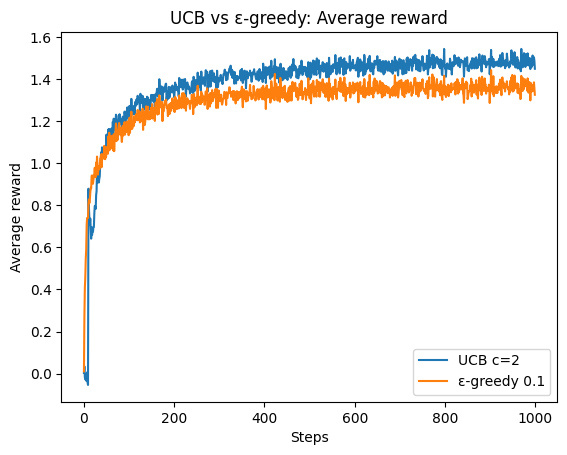

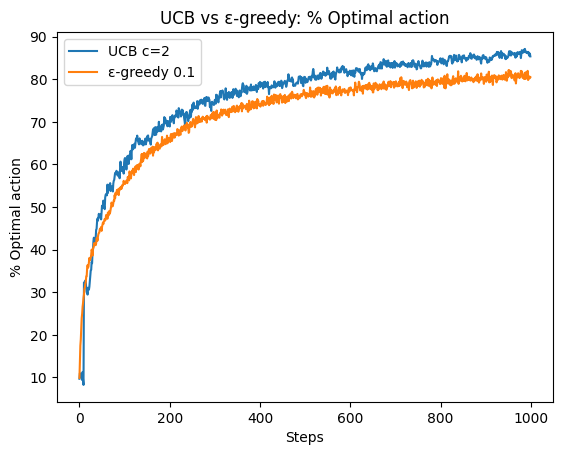

In [8]:
# Comparison of UCB vs ε-greedy
ucb_vs_eps = [
    ("UCB c=2", lambda seed: UCB(k=k, c=2.0, alpha=None, q_init=0.0, seed=seed)),
    ("ε-greedy 0.1", lambda seed: EpsilonGreedy(k=k, epsilon=0.1, alpha=None, q_init=0.0, seed=seed)),
]
results2 = []
for name, factory in ucb_vs_eps:
    avg_r, opt_pct = run_testbed(factory, runs=runs, steps=steps, k=k, stationary=True, seed=456)
    results2.append((name, avg_r, opt_pct))

plt.figure()
for name, avg_r, _ in results2:
    plt.plot(avg_r, label=name)
plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.title("UCB vs ε-greedy: Average reward")
plt.legend()
plt.show()

plt.figure()
for name, _, opt_pct in results2:
    plt.plot(opt_pct, label=name)
plt.xlabel("Steps")
plt.ylabel("% Optimal action")
plt.title("UCB vs ε-greedy: % Optimal action")
plt.legend()
plt.show()

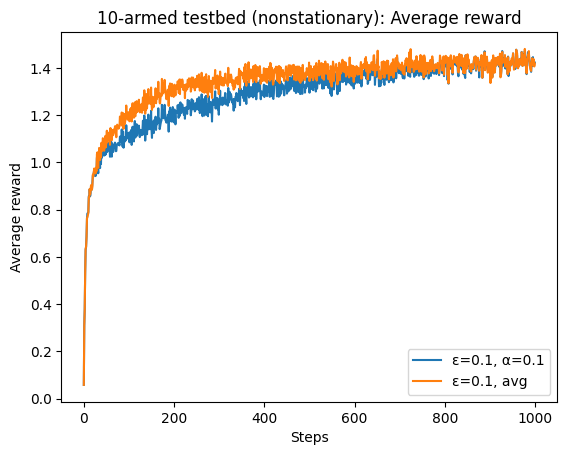

In [10]:
# Comparison of sample-average vs constant step-size in nonstationary case
nonstationary = [
    ("ε=0.1, α=0.1", lambda seed: EpsilonGreedy(k=k, epsilon=0.1, alpha=0.1, q_init=0.0, seed=seed)),
    ("ε=0.1, avg", lambda seed: EpsilonGreedy(k=k, epsilon=0.1, alpha=None, q_init=0.0, seed=seed)),
]
results3 = []
for name, factory in nonstationary:
    avg_r, opt_pct = run_testbed(factory, runs=runs, steps=steps, k=k, stationary=False, reward_std=0.01, seed=789)
    results3.append((name, avg_r, opt_pct))

plt.figure()
for name, avg_r, _ in results3:
    plt.plot(avg_r, label=name)
plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.title("10-armed testbed (nonstationary): Average reward")
plt.legend()
plt.show()